## Setup

In [1]:
%load_ext rpy2.ipython
%load_ext autoreload
%autoreload 2

%matplotlib inline  
from matplotlib import rcParams
rcParams['figure.figsize'] = (16, 100)

import warnings
from rpy2.rinterface import RRuntimeWarning
warnings.filterwarnings("ignore") # Ignore all warnings
# warnings.filterwarnings("ignore", category=RRuntimeWarning) # Show some warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

Error importing in API mode: ImportError('On Windows, cffi mode "ANY" is only "ABI".')
Trying to import in ABI mode.
Failed to read module file 'c:\Python313\Lib\_strptime.py' for module '_strptime': UnicodeDecodeError
Traceback (most recent call last):
  File "C:\Users\craig\AppData\Roaming\Python\Python313\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
  File "C:\Users\craig\AppData\Roaming\Python\Python313\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
  File "c:\Python313\Lib\importlib\__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1387, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._boot

In [2]:
%%javascript
// Disable auto-scrolling
IPython.OutputArea.prototype._should_scroll = function(lines) {
    return false;
}

<IPython.core.display.Javascript object>

## TidyCensus Example

This notebook grabs data from the US Census using the [tidycensus package in R](https://walker-data.com/tidycensus/index.html). Make sure you have installed the `tidyverse` and `tidycensus` packages.

In [3]:
%%R 

library(tidycensus)
library(tidyverse)

# store any shapefiles we grab from the census in ~/Library/Caches/tigris
# in case the government removes the shapefiles FTP server again 😭
options(tigris_use_cache = TRUE)

-- Attaching core tidyverse packages ------------------------ tidyverse 2.0.0 --
v dplyr     1.1.4     v readr     2.1.6
v forcats   1.0.1     v stringr   1.6.0
v ggplot2   4.0.1     v tibble    3.3.1
v lubridate 1.9.4     v tidyr     1.3.2
v purrr     1.2.1     
-- Conflicts ------------------------------------------ tidyverse_conflicts() --
x dplyr::filter() masks stats::filter()
x dplyr::lag()    masks stats::lag()
i Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


### Step 1 \| Get a Census API key

Get a Census API key [here](https://api.census.gov/data/key_signup.html).

Then make a new file called `.env` in this folder and put it in there. 

The `.env` file should look like this:

```bash
CENSUS_API_KEY="your-api-key-here"
```

This is what is known as an environment variable. We load it below in Python

In [4]:
from dotenv import load_dotenv
load_dotenv() # <- searches for a file named .env and loads the environment variables in it

True

In [5]:
%%R 
# passes the CENSUS_API_KEY environment variable we loaded
# in Python above to R (specifically to the tidycensus package)
census_api_key(Sys.getenv("CENSUS_API_KEY"))

To install your API key for use in future sessions, run this function with `install = TRUE`.


### Step 2 \| Figure out what tables you want data from and at what geographic granularity

Use <https://censusreporter.org/> to figure out which tables you want.

-   Scroll to the bottom of the page to see the tables.
-   If you already know the table ID, stick that in the "Explore" section to learn more about that table.

Once you've found the variable or variables you want, you can plug them into this code under `variables`. 

In [30]:
%%R 

# the variable B01003_001 was selectd from the census table 
# for population, which we found in censusreporter here:
# https://censusreporter.org/tables/B01003/


# Here are the various geographies you can use with tidycensus
# https://walker-data.com/tidycensus/articles/basic-usage.html#geography-in-tidycensus

# Get variable from ACS
nyc_census_data <- get_acs(geography = "tract", 
                      state='NY',
                      county = c("New York", "Kings", "Queens", "Bronx", "Richmond"),
                      variables = c(
                        over_65_speaks_onlyenglish ='B16007_015',
                        over_65_speaks_spanish ='B16007_016',
                        over_65_speaks_indoeuropean ='B16007_018',
                        over_65_speaks_asian_pacisl ='B16007_019'
                      ),
                      year = 2021,
                      survey="acs5",
                      geometry=T)

# save to csv
write_csv(nyc_census_data, "nyc.csv")
nyc_census_data



Simple feature collection with 9308 features and 5 fields (with 4 geometries empty)
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -74.25609 ymin: 40.4961 xmax: -73.70036 ymax: 40.91771
Geodetic CRS:  NAD83
First 10 features:
         GEOID                                       NAME
1  36081014700  Census Tract 147, Queens County, New York
2  36081014700  Census Tract 147, Queens County, New York
3  36081014700  Census Tract 147, Queens County, New York
4  36081014700  Census Tract 147, Queens County, New York
5  36047058400   Census Tract 584, Kings County, New York
6  36047058400   Census Tract 584, Kings County, New York
7  36047058400   Census Tract 584, Kings County, New York
8  36047058400   Census Tract 584, Kings County, New York
9  36061006900 Census Tract 69, New York County, New York
10 36061006900 Census Tract 69, New York County, New York
                      variable estimate moe                       geometry
1   over_65_speaks_onlyenglish      233  

Getting data from the 2017-2021 5-year ACS
Using FIPS code '36' for state 'NY'
Using FIPS code '061' for 'New York County'
Using FIPS code '047' for 'Kings County'
Using FIPS code '081' for 'Queens County'
Using FIPS code '005' for 'Bronx County'
Using FIPS code '085' for 'Richmond County'


### Step 3 | Pivot to Wide Format

Pivot from long to wide using `pivot_wider`.

Depending on what you're trying to do, you may want the data in long or wide format. This example pivots the data to wide format, which will help us with mapping later on in the notebook.

In [31]:
%%R 

nyc_census_data <- nyc_census_data %>% 
  pivot_wider(
    names_from=variable, 
    values_from = c(estimate, moe),
    names_glue = "{variable}_{.value}"
  )# pivot from wide to long

nyc_census_data

Simple feature collection with 2327 features and 10 fields (with 1 geometry empty)
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -74.25609 ymin: 40.4961 xmax: -73.70036 ymax: 40.91771
Geodetic CRS:  NAD83
# A tibble: 2,327 x 11
   GEOID       NAME                              geometry over_65_speaks_onlye~1


R callback write-console: <class 'UnicodeDecodeError'> 'utf-8' codec can't decode byte 0xb0 in position 54: invalid start byte <traceback object at 0x0000012F7ACEC440>


 1 36081014700 Census Tract 14~ (((-73.9137 40.76548, -7~                    233
 2 36047058400 Census Tract 58~ (((-73.96103 40.59616, -~                    105
 3 36061006900 Census Tract 69~ (((-74.02064 40.73039, -~                    318
 4 36047073000 Census Tract 73~ (((-73.93345 40.6257, -7~                    375
 5 36047100400 Census Tract 10~ (((-73.90735 40.63083, -~                    253
 6 36047055700 Census Tract 55~ (((-73.96279 40.72256, -~                      6
 7 36005022101 Census Tract 22~ (((-73.92012 40.83759, -~                    260
 8 36081047000 Census Tract 47~ (((-73.78059 40.71343, -~                    117
 9 36047050402 Census Tract 50~ (((-73.97496 40.6478, -7~                    197
10 36047028501 Census Tract 28~ (((-73.94439 40.70043, -~                     12
# i 2,317 more rows
# i abbreviated name: 1: over_65_speaks_onlyenglish_estimate
# i 7 more variables: over_65_speaks_spanish_estimate <dbl>,
#   over_65_speaks_indoeuropean_estimate <dbl>,


### Step 4 | Do calculations with `mutate`

In R, you can use `mutate` to create new columns or modify existing ones.

In this example, we create a column called `borough` by extracting the borough from the `NAME` column.

_(hint, I used GitHub Copilot -- a tool similar to ChatGPT -- to do this...see my prompt in the comments)_

In [38]:
%%R 

# Extract borough name from NAME by splitting strings like "Census Tract 147, Queens County, New York" 
# on commas and extracting the second to last element

nyc_census_data <- nyc_census_data %>% 
    mutate(
        borough = str_split(NAME, ",") %>% map_chr(2) %>% str_trim(),
    ) 

nyc_census_data


Simple feature collection with 2327 features and 11 fields (with 1 geometry empty)
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -74.25609 ymin: 40.4961 xmax: -73.70036 ymax: 40.91771
Geodetic CRS:  NAD83
# A tibble: 2,327 x 12
   GEOID       NAME                              geometry over_65_speaks_onlye~1


R callback write-console: <class 'UnicodeDecodeError'> 'utf-8' codec can't decode byte 0xb0 in position 54: invalid start byte <traceback object at 0x0000012F7ACA4A00>


 1 36081014700 Census Tract 14~ (((-73.9137 40.76548, -7~                    233
 2 36047058400 Census Tract 58~ (((-73.96103 40.59616, -~                    105
 3 36061006900 Census Tract 69~ (((-74.02064 40.73039, -~                    318
 4 36047073000 Census Tract 73~ (((-73.93345 40.6257, -7~                    375
 5 36047100400 Census Tract 10~ (((-73.90735 40.63083, -~                    253
 6 36047055700 Census Tract 55~ (((-73.96279 40.72256, -~                      6
 7 36005022101 Census Tract 22~ (((-73.92012 40.83759, -~                    260
 8 36081047000 Census Tract 47~ (((-73.78059 40.71343, -~                    117
 9 36047050402 Census Tract 50~ (((-73.97496 40.6478, -7~                    197
10 36047028501 Census Tract 28~ (((-73.94439 40.70043, -~                     12
# i 2,317 more rows
# i abbreviated name: 1: over_65_speaks_onlyenglish_estimate
# i 8 more variables: over_65_speaks_spanish_estimate <dbl>,
#   over_65_speaks_indoeuropean_estimate <dbl>,


### Step 5 | Example Plots

Let's practice with histograms

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


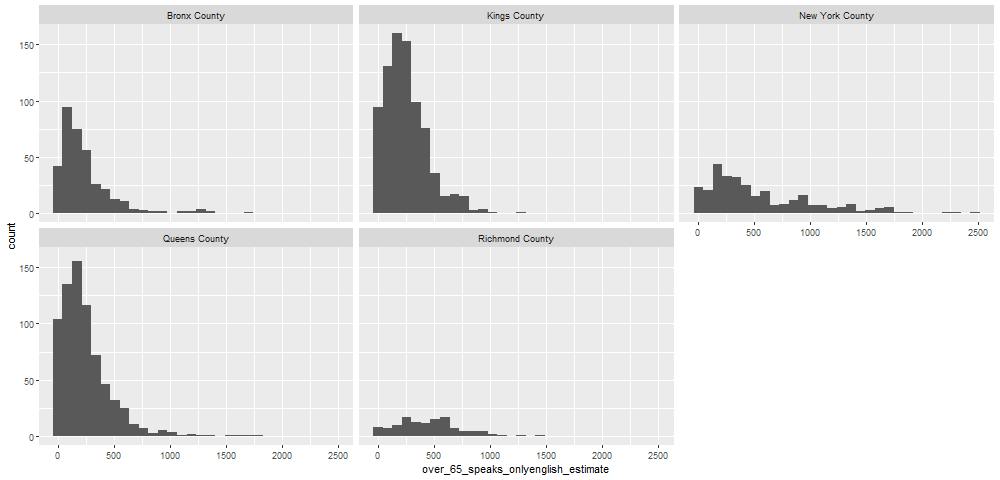

In [39]:
%%R -w 1000

ggplot(nyc_census_data) + 
    aes(x=over_65_speaks_onlyenglish_estimate) +
    geom_histogram() +
    facet_wrap('borough')
   

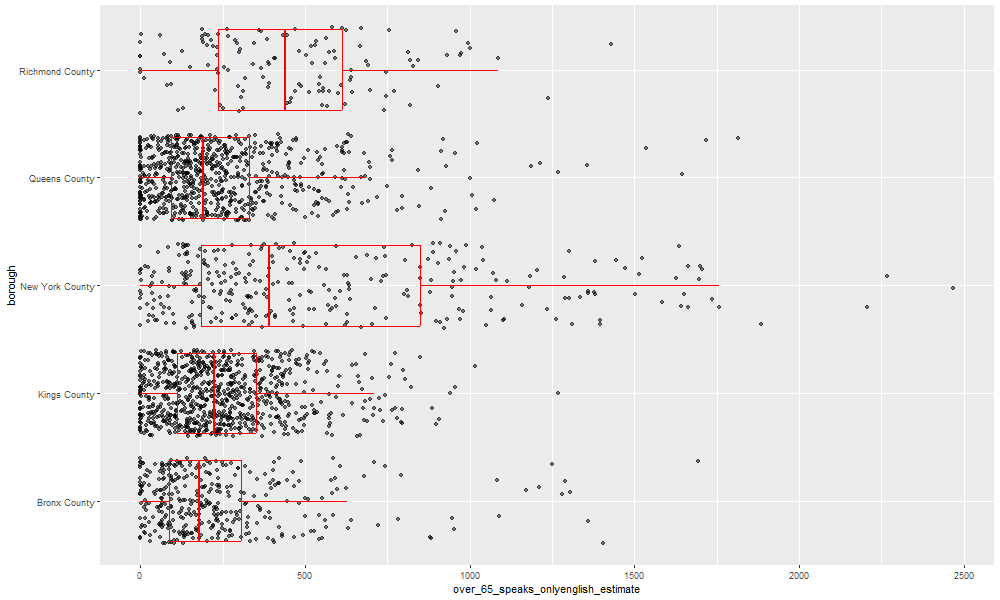

In [41]:
%%R -w 1000 -h 600

ggplot(nyc_census_data) + 
    aes(x=over_65_speaks_onlyenglish_estimate, y=borough) +
    geom_jitter(alpha=0.5) + 
    # overlay a box and whisker plot that is transparent with no outliers and is red
    geom_boxplot(fill=NA, outlier.shape=NA, color="red") 

### Step 6 \| Example Map

See more details about making maps here:

https://walker-data.com/tidycensus/articles/spatial-data.html

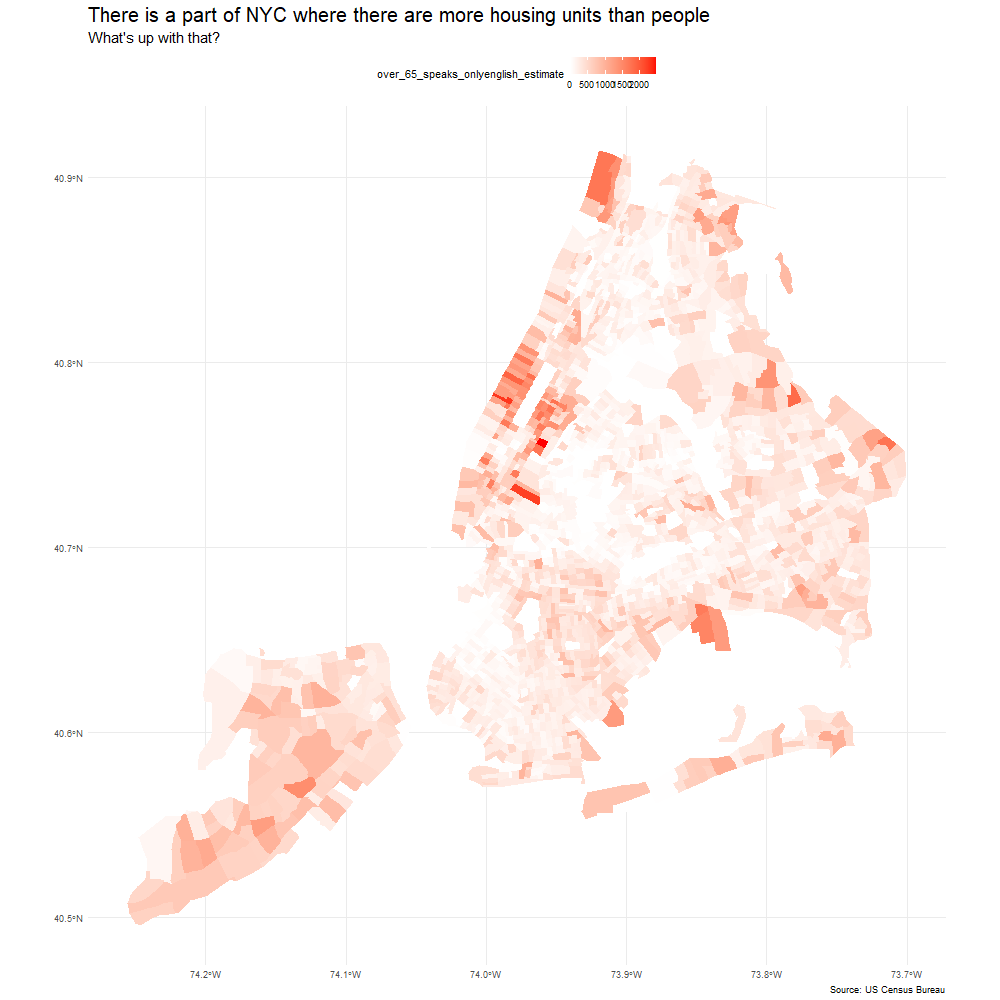

In [42]:
%%R -w 1000 -h 1000

nyc_census_data %>%
  ggplot(aes(fill = over_65_speaks_onlyenglish_estimate)) + 
  geom_sf(color = NA) + 
  scale_fill_gradient(low="white", high="red") + 
  theme_minimal() +
  labs(
    title = "There is a part of NYC where there are more housing units than people",
    subtitle = "What's up with that?",
    caption = "Source: US Census Bureau"
  ) +
  theme(
    #make title and subitle bigger
    plot.title = element_text(size = 20),
    plot.subtitle = element_text(size = 15),
    # move legend to top
    legend.position = "top"
  )


## Bonus 🤔

Hmm...that map looks weird. What happened to the east river (the one that separates Queens from Manhattan). How can we fix it? Google around and see if you can find a tutorial to help you figure out the problem and fix it. Then, correct the mistake in the map above.

In [ ]:
# What terms did you search for to find the answer? Link to the source of the answer (or the chatbot conversation) here:

# 👉